In [8]:
import networkx as nx
import matplotlib.pyplot as plt
from typing import Dict, Any, Optional
import json
from PIL import Image


def visualize_skeleton(skeleton_data: Dict[str, Any], image_path: Optional[str] = None) -> None:
    """
    Visualize the skeleton graph from JSON data, optionally alongside the original image

    Args:
        skeleton_data: Dictionary containing the graph data with nodes and links
        image_path: Optional path to the original image to display alongside the graph
    """
    # Create figure with one or two subplots
    if image_path:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
        # Display original image
        img = Image.open(image_path)
        ax1.imshow(img)
        ax1.set_title("Original Image")
        ax1.axis('off')
        current_ax = ax2
    else:
        fig, current_ax = plt.subplots(figsize=(10, 10))

    # Create an empty undirected graph
    G = nx.Graph()

    # Add nodes with positions
    pos = {}
    for node in skeleton_data["nodes"]:
        G.add_node(node["id"])
        pos[node["id"]] = (node["x"], node["y"])

    # Add edges
    for link in skeleton_data["links"]:
        G.add_edge(link["source"], link["target"])

    # Draw the graph
    nx.draw(
        G,
        pos=pos,
        node_color="lightblue",
        node_size=500,
        with_labels=True,
        font_size=8,
        font_weight="bold",
        edge_color="gray",
        width=2,
        ax=current_ax
    )

    current_ax.set_title("Skeleton Graph Visualization")
    current_ax.invert_yaxis()
    current_ax.axis("equal")
    plt.show()



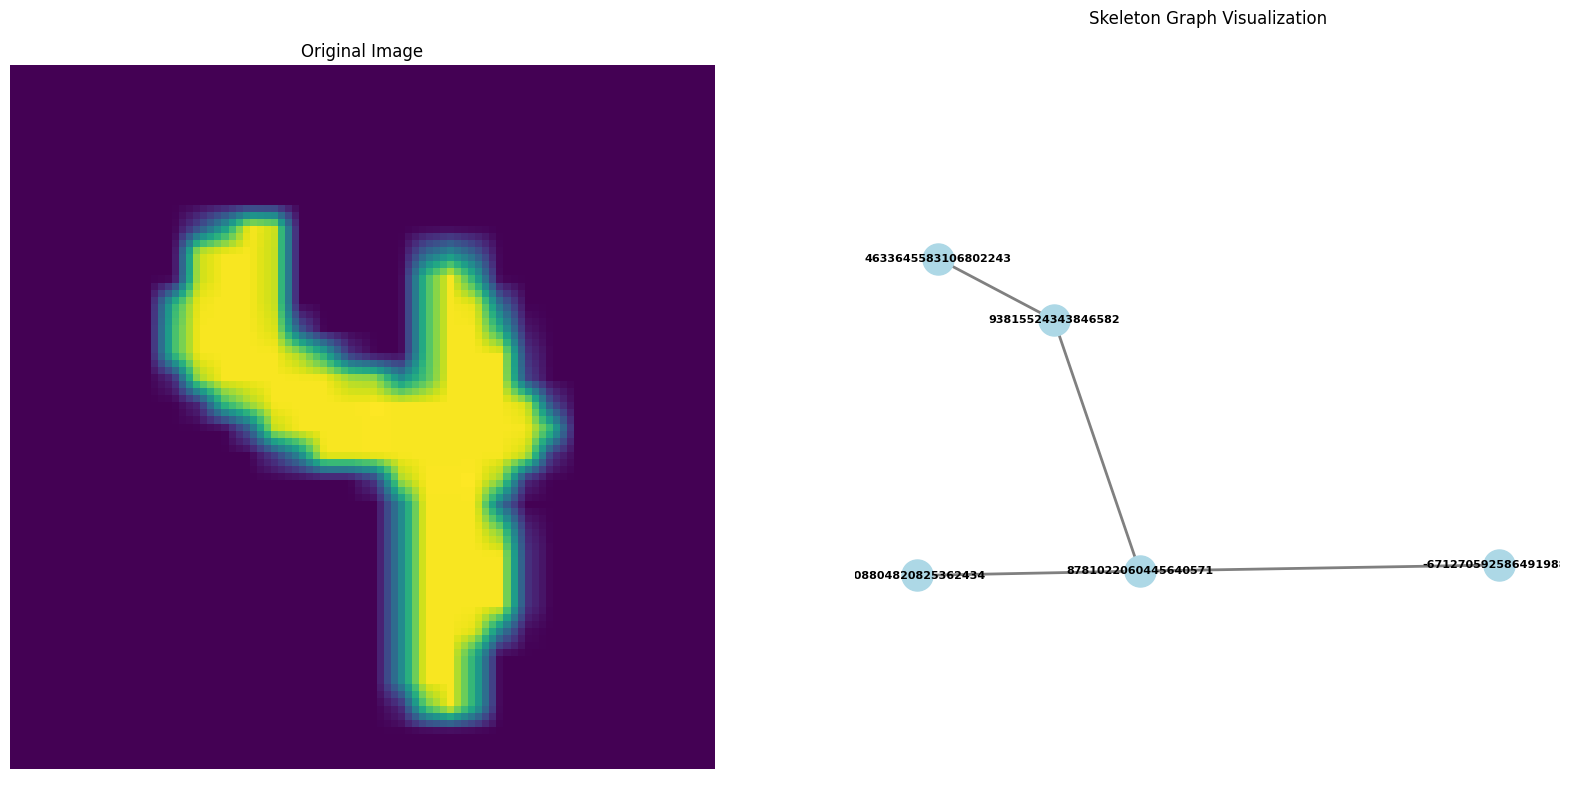

In [9]:
# Example usage with the provided JSON data
skeleton_data = {
    "directed": False,
    "multigraph": False,
    "graph": {},
    "nodes": [
        {
            "x": 33.539448832451065,
            "y": 31.000000000000007,
            "uuid": "80a2b771-e686-4cdd-a864-8f0f72070896",
            "id": 4633645583106802243,
        },
        {
            "x": 44.93269941130866,
            "y": 37.00941921582294,
            "uuid": "5d377b9f-bb9e-4f3b-abd3-749c15f90c62",
            "id": 93815524343846582,
        },
        {
            "x": 53.329241894136864,
            "y": 61.59821800617775,
            "uuid": "95001d2c-53fc-42ec-9ca5-585b53a19c92",
            "id": 8781022060445640571,
        },
        {
            "x": 88.48523351648025,
            "y": 61.000000000000014,
            "uuid": "6bda96da-d3fe-40bc-b1ee-d0b5b713b9e8",
            "id": -6712705925864919884,
        },
        {
            "x": 31.48689956331893,
            "y": 62.0272925764193,
            "uuid": "f5bd989f-bb80-4709-92e9-d34bd461a871",
            "id": 108804820825362434,
        },
    ],
    "links": [
        {
            "segment_id": 3,
            "uuid": "9e2a5d0a-2610-462d-8d05-11a7ae7ff6b2",
            "x1": 44.93269941130866,
            "y1": 37.00941921582294,
            "x2": 33.539448832451065,
            "y2": 31.000000000000007,
            "length": 12.880965727154965,
            "source": 4633645583106802243,
            "target": 93815524343846582,
        },
        {
            "segment_id": 3,
            "uuid": "9c3e3508-0ac3-49d6-871c-19122bea3b60",
            "x1": 53.329241894136864,
            "y1": 61.59821800617775,
            "x2": 44.93269941130866,
            "y2": 37.00941921582294,
            "length": 25.98289729068899,
            "source": 93815524343846582,
            "target": 8781022060445640571,
        },
        {
            "segment_id": 2,
            "uuid": "9e4e5a33-ce77-4403-965e-f8ac0db8abe7",
            "x1": 88.48523351648025,
            "y1": 61.000000000000014,
            "x2": 53.329241894136864,
            "y2": 61.59821800617775,
            "length": 35.16108092384524,
            "source": 8781022060445640571,
            "target": -6712705925864919884,
        },
        {
            "segment_id": 5,
            "uuid": "434ef29e-5670-40f8-a828-d5aae5b3cb63",
            "x1": 31.48689956331893,
            "y1": 62.0272925764193,
            "x2": 53.329241894136864,
            "y2": 61.59821800617775,
            "length": 21.846556330082528,
            "source": 8781022060445640571,
            "target": 108804820825362434,
        },
    ],
}

visualize_skeleton(
    skeleton_data, "../../tests/generated_samples/mnist_4/test/mnist_4_00008.png"
)

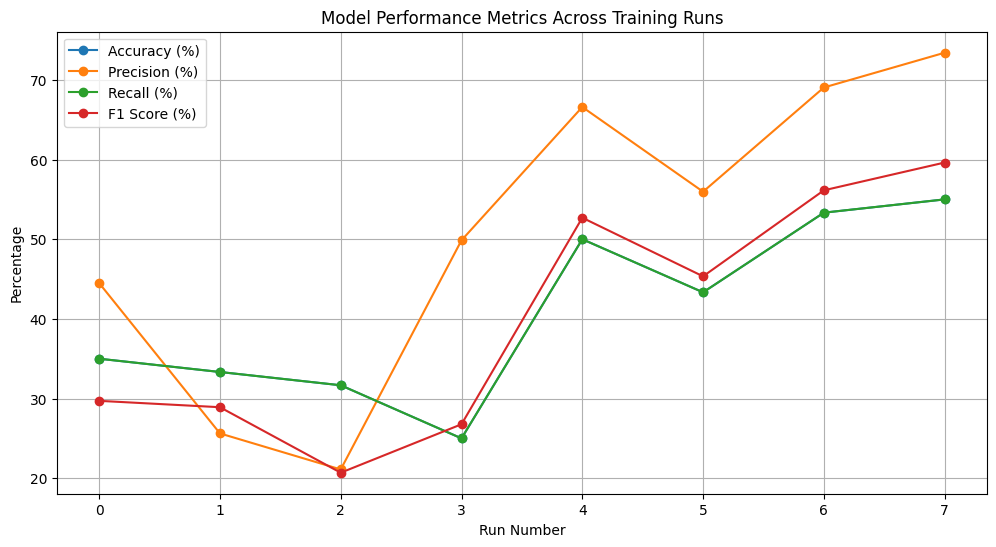

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from typing import List

def load_metrics_files(training_results_dir: str) -> List[pd.DataFrame]:
    """Load all metrics.csv files from training results directory"""
    metrics_files = list(Path(training_results_dir).glob('*/metrics.csv'))
    return [pd.read_csv(f) for f in sorted(metrics_files)]

def plot_metrics_over_runs(metrics_dfs: List[pd.DataFrame]) -> None:
    """Plot key metrics across training runs"""
    metrics_to_plot = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1 Score (%)']
    
    plt.figure(figsize=(12, 6))
    x = range(len(metrics_dfs))
    
    for metric in metrics_to_plot:
        values = [df[df['Metric'] == metric]['Value'].values[0] for df in metrics_dfs]
        plt.plot(x, values, marker='o', label=metric)
    
    plt.xlabel('Run Number')
    plt.ylabel('Percentage')
    plt.title('Model Performance Metrics Across Training Runs')
    plt.legend()
    plt.grid(True)
    plt.show()

# Load and plot metrics from training results
metrics_dfs = load_metrics_files('training_results')
plot_metrics_over_runs(metrics_dfs)
